In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle


# import visual_behavior.data_access.loading as loading # Files should be saved in a clear location
# import visual_behavior.data_access.utilities as utilities
import visual_behavior.visualization.utils as utils

import seaborn as sns
import matplotlib.colors
sns.set_context('notebook', font_scale=1.5, rc={'lines.markeredgewidth': 1})

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from visual_behavior.dimensionality_reduction.clustering import plotting # functions to plot clusters
from visual_behavior.dimensionality_reduction.clustering import processing # function for computing and validating clusters

import visual_behavior.visualization.ophys.platform_paper_figures as ppf

In [4]:
import visual_behavior_glm.GLM_fit_dev as gfd
import visual_behavior_glm.GLM_analysis_tools as gat
import visual_behavior_glm.GLM_across_session as gas

In [5]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [6]:
run_examples = False # skip example runs to run the notebook faster

#### Load original data

In [7]:
experience_level_colors = utils.get_experience_level_colors()
cre_line_colors = utils.get_cre_line_colors()

experience_levels = utils.get_new_experience_levels()
cell_types = utils.get_cell_types()

In [8]:
# path to data file
base_path = '//allen/programs/braintv/workgroups/nc-ophys/visual_behavior/platform_paper_cache_new'
#base_path = os.path.abspath(path)

# create folder to load and save to
folder = 'clustering'
save_dir = os.path.join(base_path, folder)


In [9]:
fig_path = '//allen/programs/braintv/workgroups/nc-ophys/visual_behavior/platform_paper_figures_final'


# Familiar control

## Supplemental figure 24

In [10]:
cells_table = processing.get_cells_matched_in_3_familiar_active_sessions()
# add unique identifier for ophys_expt_id + csid pairs so it can be merged with results_pivoted
cells_table['identifier'] = [str(cells_table.iloc[row].ophys_experiment_id)+'_'+str(cells_table.iloc[row].cell_specimen_id) for row in range(len(cells_table))]
cells_table = cells_table.set_index('identifier')

1244 experiments
452 familiar active experiments
['Familiar']
['OPHYS_1_images_A' 'OPHYS_3_images_A' 'OPHYS_1_images_B'
 'OPHYS_3_images_B']
445 experiments in filtered cells table
17957 familiar active cell_specimen_ids
17957 familiar active cell_specimen_ids
5 familiar active session numbers
checking session counts: [3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]
1432 cell_specimen_ids in at least 3 sessions
['Familiar']
['OPHYS_3_images_A' 'OPHYS_1_images_A' 'OPHYS_1_images_B'
 'OPHYS_3_images_B']
1432 familiar active cell_specimen_ids in the first 3 sessions
3 familiar active session numbers
1432 familiar active cell_specimen_ids
1432 familiar active cell_specimen_ids
3 familiar active session numbers
experience_levels:  ['Familiar 1' 'Familiar 2' 'Familiar 3']


In [11]:
version = '24_events_all_L2_optimize_by_session'

run_params, results, results_pivoted, weights_df = gfd.load_analysis_dfs(version)

loading run_params
loading results df
loading results_pivoted df
loading weights_df


In [12]:
# add new experience levels for familiar active sessions to results pivoted
# and limit results pivoted to cells matched in 3 familiar sessions
results_pivoted = results_pivoted.drop(columns='experience_level')
results_pivoted = results_pivoted.merge(cells_table[[ 'experience_level']], on='identifier')
results_pivoted.experience_level.unique()

array(['Familiar 1', 'Familiar 2', 'Familiar 3'], dtype=object)

In [13]:
print(len(results_pivoted.ophys_experiment_id.unique()))
print(len(results_pivoted.cell_specimen_id.unique()))
print(results_pivoted.project_code.unique())
print(results_pivoted.session_type.unique())

165
1432
['VisualBehaviorTask1B' 'VisualBehavior' 'VisualBehaviorMultiscope']
['OPHYS_1_images_B' 'OPHYS_3_images_B' 'OPHYS_1_images_A'
 'OPHYS_3_images_A']


In [14]:
# limit to features used for clustering
features = processing.get_features_for_clustering()
features = ['all-images', 'omissions', 'task', 'behavioral']
features = [*features, 'ophys_experiment_id']
results_pivoted = processing.limit_results_pivoted_to_features_for_clustering(results_pivoted, features)

# flip sign so coding scores are positive
results_pivoted = processing.flip_sign_of_dropouts(results_pivoted, processing.get_features_for_clustering(), use_signed_weights=False)

# now drop ophys_experiment_id
results_pivoted = results_pivoted.drop(columns=['ophys_experiment_id'])

In [15]:
save_dir_familiar = os.path.join(save_dir, 'familiar_only_clustering_without_problem_session')

In [16]:
feature_matrix = processing.get_feature_matrix_for_clustering(results_pivoted, version, save_dir=save_dir_familiar)
feature_matrix = feature_matrix.rename(columns={'all-images':'images', 'behavioral': 'behavior'})


No duplicated cells found
1432


### gap statistic

In [17]:
folder = 'figure_4/familiar_only_clustering'

In [18]:
from sklearn.cluster import SpectralClustering

metric = 'euclidean' # default distance metric
shuffle_type ='all' # default shuffle type is all shuffle (cell id and regressors
k_max = 25 #max number of clusters to test

gap_filename = os.path.join(save_dir_familiar, 'gap_scores_{}_{}_nb20_unshuffled_to_{}.pkl'.format(metric, version, shuffle_type))
if os.path.exists(gap_filename):
    with open(gap_filename, 'rb') as f:
        gap_df = pickle.load(f)
        print('loaded file')
else:
    
    sc = SpectralClustering()
    gap_df = processing.compute_gap(clustering=sc, data=feature_matrix, k_max = k_max, 
                                    reference_shuffle=shuffle_type, metric=metric, separate_cre_lines=True)
    processing.save_clustering_results(gap_df, gap_filename)

shuffle_dropout_score function: Feature matrix consists of multiple cre lines, going to shuffle dropout scores within cre lines, and combined them afterwards.
using within cre line shuffle to create reference data for gap statistic. Cre lines are hardcoded [Slc17a7-IRES2-Cre, Sst-IRES-Cre, Vip-IRES-Cre]
removing 1 problematic experiments
shuffling all data
removing 1 problematic experiments
shuffling all data
removing 1 problematic experiments
shuffling all data
shuffle_dropout_score function: Feature matrix consists of multiple cre lines, going to shuffle dropout scores within cre lines, and combined them afterwards.
using within cre line shuffle to create reference data for gap statistic. Cre lines are hardcoded [Slc17a7-IRES2-Cre, Sst-IRES-Cre, Vip-IRES-Cre]
removing 1 problematic experiments
shuffling all data
removing 1 problematic experiments
shuffling all data
removing 1 problematic experiments
shuffling all data
shuffle_dropout_score function: Feature matrix consists of multipl

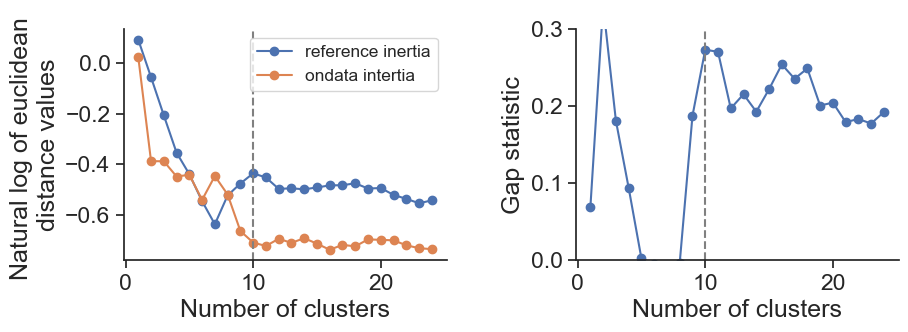

In [19]:

plotting.plot_gap_statistic(gap_df, cre_lines=['all'], n_clusters_cre=10, 
                            tag='with_cre_shuffle', save_dir=fig_path, folder=folder)

### panel b and c - coclustering matrix

In [20]:
# number of optimal clusters
n_clusters = 10

coclust_filename = os.path.join(save_dir_familiar, 'coclustering_matrix_n_' + str(n_clusters) + '_clusters.h5')

if os.path.exists(coclust_filename):
    coclustering_df = pd.read_hdf(coclust_filename, key='df')
    print('found and loaded cached coclustering matrix file...')
else:
    print('did not find cached coclustering matrix file, will make one...')
    sc = SpectralClustering()
    X = feature_matrix.values
    m = processing.get_coClust_matrix(X=X, n_clusters=n_clusters, model=sc, nboot=np.arange(150))
    # make co-clustering matrix a dataframe with cell_specimen_ids as indices and columns
    coclustering_df = pd.DataFrame(data=m, index=feature_matrix.index, columns=feature_matrix.index)

    # save co-clustering matrix
    coclust_save_file = os.path.join(save_dir_familiar, 'coclustering_matrix_n_' + str(n_clusters) + '_clusters.h5')
    coclustering_df.to_hdf(coclust_filename, key='df', format='table')
    print('created and saved coclustering_matrix file.')

did not find cached coclustering matrix file, will make one...


100%|██████████| 150/150 [03:28<00:00,  1.39s/it]


created and saved coclustering_matrix file.


In [21]:
save_dir

'//allen/programs/braintv/workgroups/nc-ophys/visual_behavior/platform_paper_cache_new\\clustering'

In [22]:
save_dir_familiar

'//allen/programs/braintv/workgroups/nc-ophys/visual_behavior/platform_paper_cache_new\\clustering\\familiar_only_clustering_without_problem_session'

In [23]:
n_clusters = 10 # based on eigen gap

cluster_meta_save_path = os.path.join(save_dir_familiar, 'cluster_meta_n_'+str(n_clusters)+'_clusters.h5')

# if clustering output exists, load it
if os.path.exists(cluster_meta_save_path):
    print('loading results')
    cluster_meta = pd.read_hdf(cluster_meta_save_path, key='df')
    # merge in cell metadata
    cell_metadata = processing.get_cell_metadata_for_feature_matrix(feature_matrix, cells_table)
    cell_metadata = cell_metadata.drop(columns=['ophys_experiment_id', 'cre_line'])
    cluster_meta = cluster_meta.merge(cell_metadata.reset_index(), on='cell_specimen_id')
    cluster_meta = cluster_meta.set_index('cell_specimen_id')
# otherwise run it and save it
else: 

    # run agglomerative clustering on co-clustering matrix to identify cluster labels
    from sklearn.cluster import AgglomerativeClustering
    X = coclustering_df.values
    cluster = AgglomerativeClustering(n_clusters=n_clusters, affinity='euclidean',
                                    linkage='average')
    labels = cluster.fit_predict(X)
    cell_specimen_ids = coclustering_df.index.values
    # make dictionary with labels for each cell specimen ID in this cre line
    labels_dict = {'labels': labels, 'cell_specimen_id': cell_specimen_ids}
    # turn it into a dataframe
    labels_df = pd.DataFrame(data=labels_dict, columns=['labels', 'cell_specimen_id'])
    # get new cluster_ids based on size of clusters and add to labels_df
    cluster_size_order = labels_df['labels'].value_counts().index.values
    # translate between original labels and new IDS based on cluster size
    labels_df['cluster_id'] = [np.where(cluster_size_order == label)[0][0] for label in labels_df.labels.values]
    # concatenate with df for all cre lines
    cluster_labels = labels_df

    # limit cells_table to cells in feature_matrix and drop duplicates 
    cell_metadata = processing.get_cell_metadata_for_feature_matrix(feature_matrix, cells_table)
    # cluster_meta will only have one row per cell_specimen_id 

    cluster_meta = cluster_labels[['cell_specimen_id', 'cluster_id', 'labels']].merge(cell_metadata, on='cell_specimen_id')
    cluster_meta = cluster_meta.set_index('cell_specimen_id')
    cluster_meta['cluster_id'] = cluster_meta['cluster_id'].copy()+1
    # annotate & clean cluster metadata
    cluster_meta = processing.clean_cluster_meta(cluster_meta)  # drop cluster IDs with fewer than 5 cells in them
    cluster_meta['original_cluster_id'] = cluster_meta.cluster_id

    # add within cluster correlation
    cluster_meta = processing.add_within_cluster_corr_to_cluster_meta(feature_matrix, cluster_meta, use_spearmanr=True)

    # save clustering results
    print('saving results')
    cluster_meta_save_path = os.path.join(save_dir_familiar, 'cluster_meta_n_'+str(n_clusters)+'_clusters.h5')
    cluster_data = cluster_meta.reset_index()[['cell_specimen_id', 'ophys_experiment_id', 'cre_line', 'cluster_id', 'labels', 'within_cluster_correlation']]
    cluster_data.to_hdf(cluster_meta_save_path, key='df', format='table')


1432 cells in cell_metadata for feature_matrix
dropping 5 cells for ('Sst-IRES-Cre', 1)
dropping 3 cells for ('Sst-IRES-Cre', 4)
dropping 5 cells for ('Sst-IRES-Cre', 5)
dropping 1 cells for ('Sst-IRES-Cre', 6)
dropping 1 cells for ('Sst-IRES-Cre', 7)
dropping 5 cells for ('Sst-IRES-Cre', 8)
dropping 2 cells for ('Sst-IRES-Cre', 9)
dropping 2 cells for ('Vip-IRES-Cre', 2)
dropping 4 cells for ('Vip-IRES-Cre', 4)
dropping 4 cells for ('Vip-IRES-Cre', 5)
dropping 2 cells for ('Vip-IRES-Cre', 6)
dropping 2 cells for ('Vip-IRES-Cre', 7)
dropping 2 cells for ('Vip-IRES-Cre', 8)
38 cells dropped total
adding within cluster correlation to cluster_meta
saving results


In [24]:
coclust_save_path = os.path.join(save_dir_familiar, 'coclustering_matrix_n_'+str(n_clusters)+'_clusters.h5')
if os.path.exists(coclust_save_path):
    coclustering_df = pd.read_hdf(coclust_save_path, key='df')
else:

    from sklearn.cluster import SpectralClustering
    sc = SpectralClustering()
    X = feature_matrix.values
    m = processing.get_coClust_matrix(X=X, n_clusters=n_clusters, model=sc, nboot=np.arange(100))
    # make co-clustering matrix a dataframe with cell_specimen_ids as indices and columns
    coclustering_df = pd.DataFrame(data=m, index=feature_matrix.index, columns=feature_matrix.index)

    # save co-clustering matrix
    coclustering_df.to_hdf(coclust_save_path, key='df', format='table')


<AxesSubplot:ylabel='cells'>

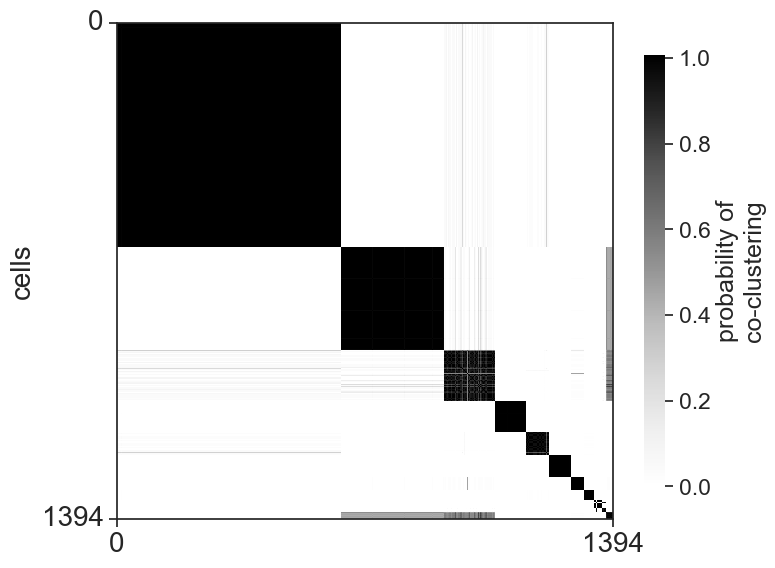

In [25]:
coclustering_dict = {}
coclustering_dict['all'] = coclustering_df
cluster_meta_tmp = cluster_meta.copy()
cluster_meta_tmp['cre_line'] = 'all'
plotting.plot_coclustering_matrix_sorted_by_cluster_size(coclustering_dict, cluster_meta_tmp, cre_line='all',
                                                                 save_dir=fig_path, folder=folder,
                                                                 suffix='_' + str(n_clusters) + '_clusters', ax=None)

### panel d and f - cluster heatmaps

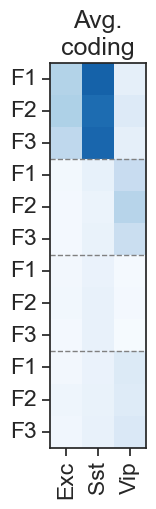

In [26]:
plotting.plot_cre_line_means_remapped(feature_matrix, cluster_meta, session_colors=False, experience_index=0)

<AxesSubplot:title={'center':'Cluster averages'}, xlabel='Cluster ID'>

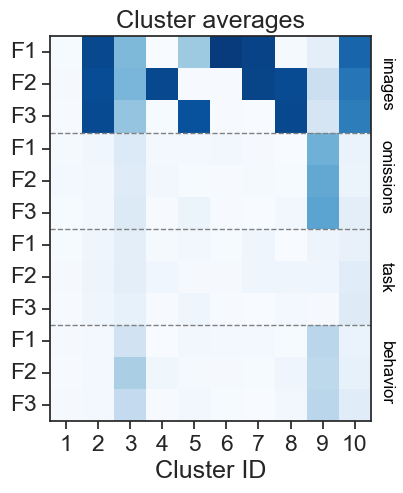

In [27]:
plotting.plot_cluster_means_remapped(feature_matrix, cluster_meta, session_colors=False,
                                     experience_index=0, save_dir=fig_path, folder=folder, ax=None)

<AxesSubplot:xlabel='Cluster ID'>

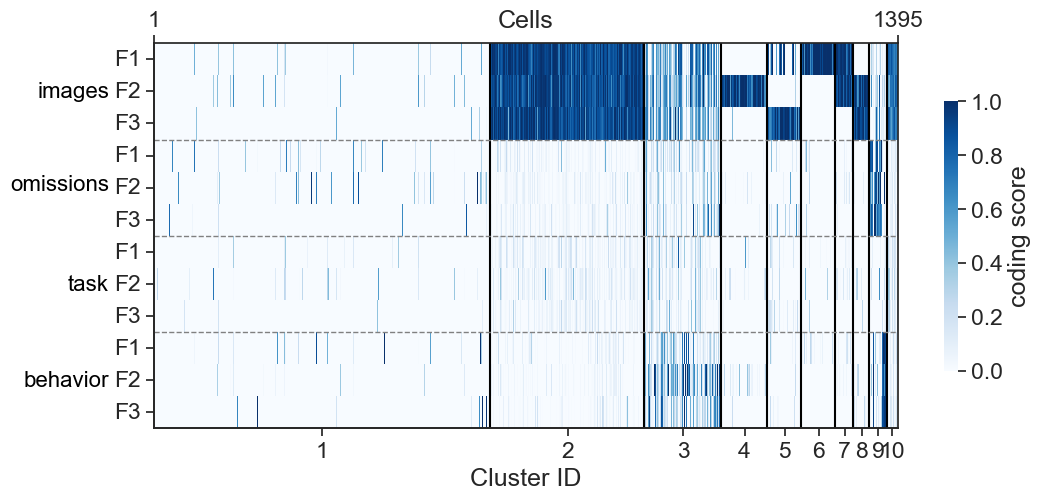

In [28]:
plotting.plot_coding_score_heatmap_remapped(cluster_meta, feature_matrix, sort_by='cluster_id', session_colors=False,
                                    experience_index=0, save_dir=fig_path, folder=folder, ax=None)

10 10
3 10
3 10


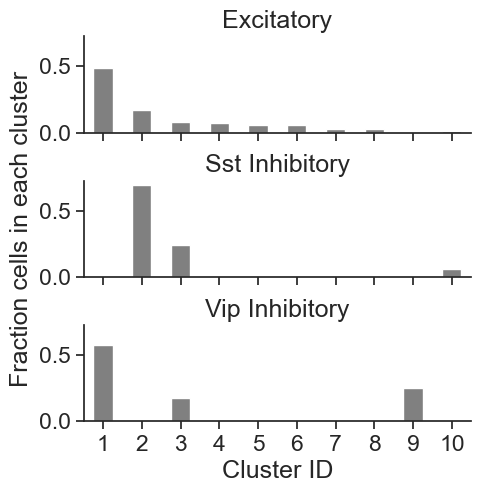

In [29]:
plotting.plot_fraction_cells_per_cluster_per_cre(cluster_meta, col_to_group='cre_line', 
                                                    save_dir=fig_path, folder=folder)

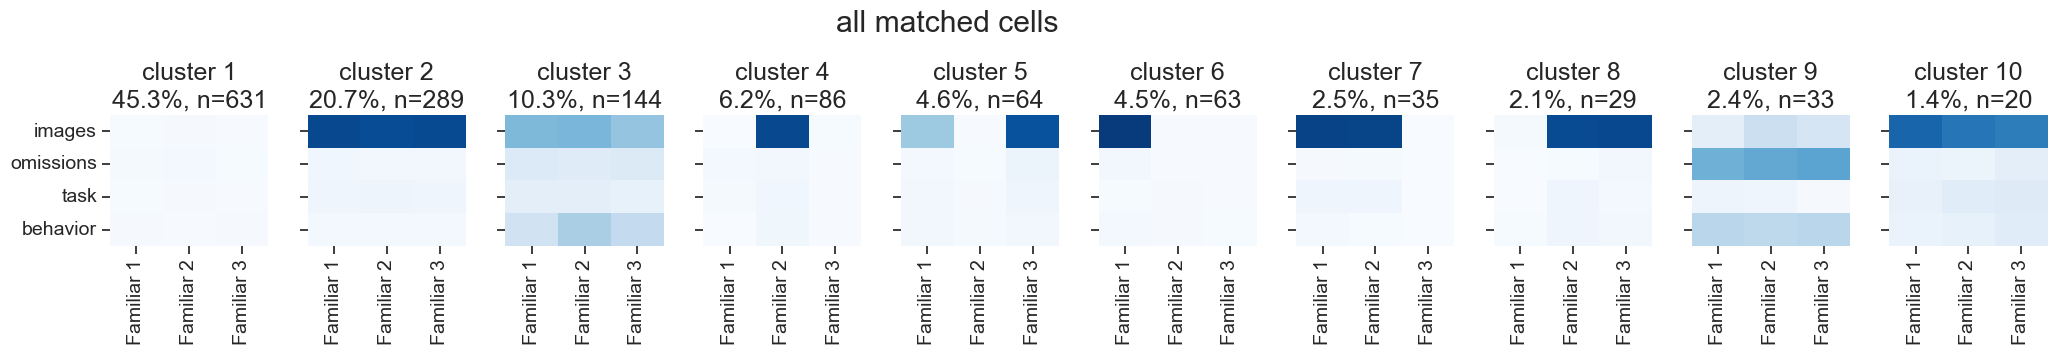

In [30]:
# plot coding scores for all clusters
clusters = cluster_meta.value_counts('cluster_id').index.values
plotting.plot_mean_cluster_heatmaps_remapped(feature_matrix, cluster_meta, None, session_colors=False, experience_index=0, save_dir=None, folder=None)

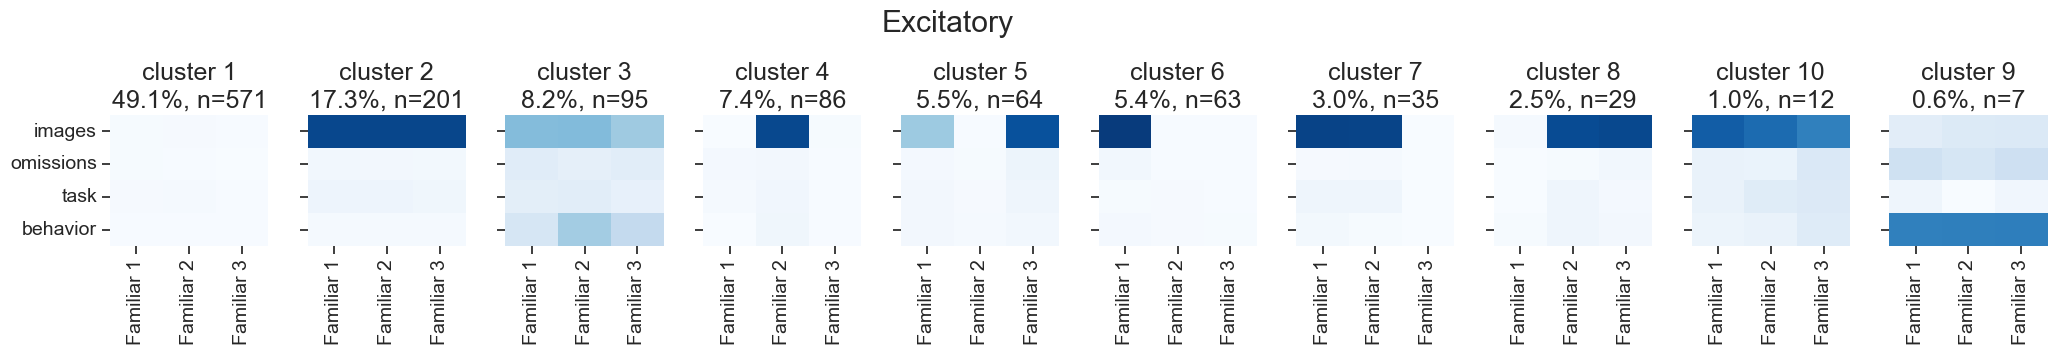

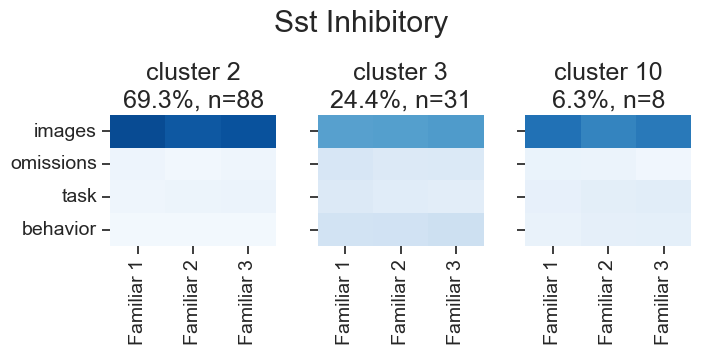

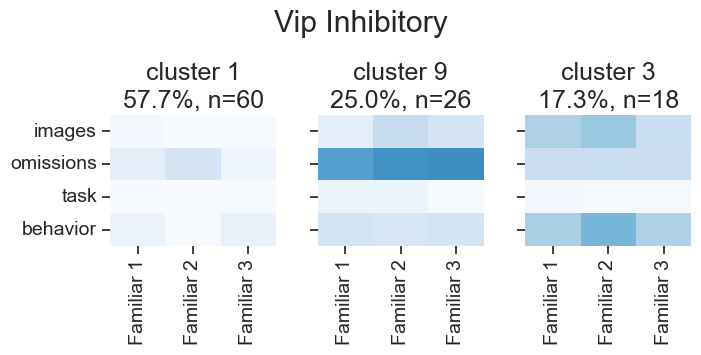

In [31]:
for cre_line in utils.get_cre_lines():
    cluster_meta_cre = cluster_meta[cluster_meta.cre_line==cre_line]
    clusters = cluster_meta_cre.value_counts('cluster_id').index.values
    plotting.plot_mean_cluster_heatmaps_remapped(feature_matrix, cluster_meta_cre, 
                                                 cre_line, session_colors=False, sort_by='cluster_size',
                                                 experience_index=0, save_dir=fig_path, folder=folder)

### Mean response traces for clusters per cre line

In [32]:
data_type = 'events'

interpolate = True
output_sampling_rate = 30

# set inclusion criteria
# options: ['active_only', 'closest_familiar_and_novel', 'containers_with_all_levels']
inclusion_criteria = ''

In [33]:
import visual_behavior.data_access.loading as loading

In [34]:
# params for stim response df creation
event_type = 'all'

# params for mean response df creation
conditions = ['cell_specimen_id', 'is_change']


change_suffix = '_'+utils.get_conditions_string(data_type, conditions)+'_'+inclusion_criteria

multi_session_df = loading.get_multi_session_df_for_conditions(data_type, event_type, conditions, inclusion_criteria, 
                                                        interpolate=interpolate, output_sampling_rate=output_sampling_rate, 
                                                         epoch_duration_mins=None)

change_mdf = multi_session_df[multi_session_df.is_change==True]

loading files from \\allen\programs\braintv\workgroups\nc-ophys\visual_behavior\platform_paper_cache_new\multi_session_mean_response_dfs\interpolate_30Hz
mean_response_df_events_all_is_change_.pkl
loading multi_session_df from saved file at \\allen\programs\braintv\workgroups\nc-ophys\visual_behavior\platform_paper_cache_new\multi_session_mean_response_dfs\interpolate_30Hz\mean_response_df_events_all_is_change_.pkl
there are 1881 experiments in the full multi_session_df
removing 1 problematic experiments
there are 1868 experiments after filtering for inclusion criteria -  


In [35]:
import visual_behavior.visualization.ophys.platform_paper_figures as ppf

In [36]:
tmp = multi_session_df.copy()
tmp = tmp[tmp.is_change==False]
# add new experience level to to mdf by merging in cells_table
tmp = tmp.drop(columns='experience_level').merge(cells_table[['cell_specimen_id', 'ophys_experiment_id', 'experience_level']], on=['ophys_experiment_id', 'cell_specimen_id'])
# add cluster_id by merging in cluster meta
tmp = tmp.merge(cluster_meta.reset_index()[['cell_specimen_id', 'cluster_id']], on='cell_specimen_id')


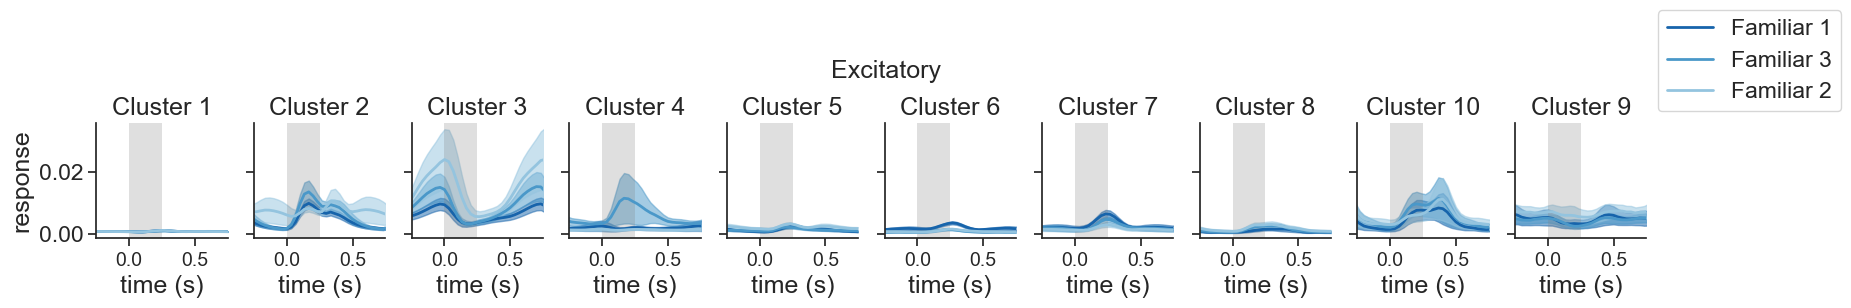

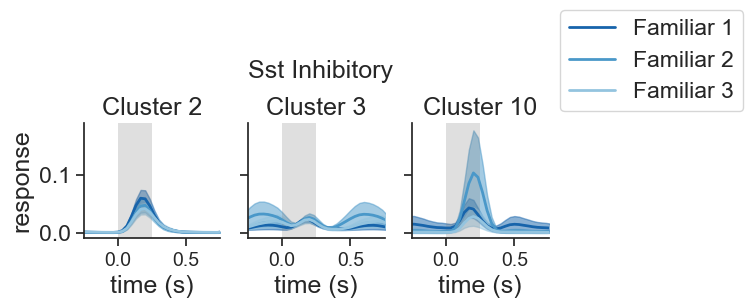

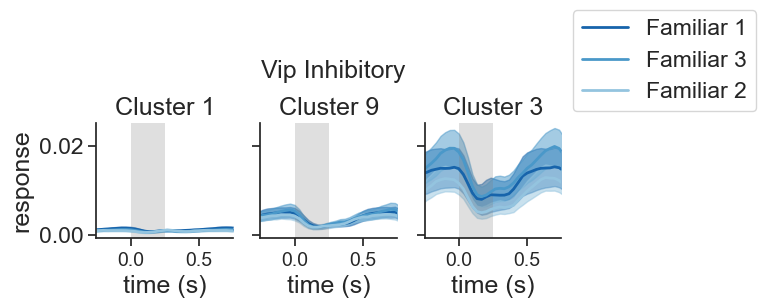

In [37]:
for cre_line in np.sort(tmp.cre_line.unique()):
    df = tmp[tmp.cre_line==cre_line].copy()

    axes_column = 'cluster_id'
    hue_column = 'experience_level'
    # xlim_seconds=[-1., 1.5]
    xlim_seconds=[-0.25, 0.75]
    cell_type = processing.get_cell_type_for_cre_line(cre_line)
    ax= plotting.plot_population_averages_for_clusters(df, event_type, axes_column, hue_column, session_colors=False, experience_index=0,legend=True,
                                            xlim_seconds=xlim_seconds, interval_sec=0.5, 
                                            sharey=True, sharex=False, 
                                            ylabel='response', xlabel='time (s)', suptitle=cell_type,
                                            save_dir=fig_path, folder=folder, suffix='_sharey', ax=None);


In [38]:
### panel e - distribution 